In [29]:
%pip install merlinquantum torch scikit-learn pandas numpy seaborn

Note: you may need to restart the kernel to use updated packages.


In [30]:
%pip uninstall merlinquantum -y

%pip install --upgrade merlinquantum

Found existing installation: merlinquantum 0.3.1
Uninstalling merlinquantum-0.3.1:
  Successfully uninstalled merlinquantum-0.3.1
Note: you may need to restart the kernel to use updated packages.
  Using cached merlinquantum-0.3.1-py3-none-any.whl.metadata (9.6 kB)
Using cached merlinquantum-0.3.1-py3-none-any.whl (197 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import itertools

from math import comb

import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import perceval as pcvl
from perceval.components import BS, PS, Circuit
from perceval.backends import BackendFactory
from itertools import permutations

from itertools import combinations_with_replacement
import re
import merlin as ML
from merlin import QuantumLayer
from datasets import load_dataset
import matplotlib.pyplot as plt
import merlin




In [5]:
ds = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train",
)

df = pd.DataFrame(ds)
df = df.drop(columns=["Date"])

data = df.values.astype(np.float64)
print("Surface shape:", data.shape)

Surface shape: (494, 224)


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

r = 5
pca = PCA(n_components=r)
factors = pca.fit_transform(data_scaled)

print("Factor shape:", factors.shape)
print("Explained variance:", np.sum(pca.explained_variance_ratio_))

Factor shape: (494, 5)
Explained variance: 0.9997859107422641


In [34]:
X = factors[:-1]                     # X_t
Y = factors[1:] - factors[:-1]       # ΔX_t

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# Torch versions (for readout training)
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
Y_test_t  = torch.tensor(Y_test,  dtype=torch.float32).to(device)

# Numpy versions (for quantum reservoir)
# X_train_np = X_train
# X_test_np  = X_test


In [ ]:
# def permanent(matrix):
#     n = matrix.shape[0]
#     perm_sum = 0
#     for p in permutations(range(n)):
#         prod = 1
#         for i in range(n):
#             prod *= matrix[i, p[i]]
#         perm_sum += prod
#     return perm_sum

In [ ]:
# m = 5      # modes
# n = 2      # photons

# circuit = Circuit(m)

# # Random interferometer
# for i in range(m - 1):
#     circuit.add(i, BS())
#     circuit.add(i, PS(np.random.uniform(0, 2*np.pi)))

# for i in reversed(range(m - 1)):
#     circuit.add(i, BS())

# U_mode = circuit.compute_unitary()

In [ ]:
# def generate_fock_basis(m, n):
#     basis = []
#     for combi in combinations_with_replacement(range(m), n):
#         state = [0] * m
#         for idx in combi:
#             state[idx] += 1
#         basis.append(tuple(state))
#     return basis

# basis = generate_fock_basis(m, n)
# dim = len(basis)

# basis_index = {state: i for i, state in enumerate(basis)}

# print("Hilbert dimension:", dim)

Hilbert dimension: 15


In [ ]:
# def build_fock_unitary(U_mode, basis):

#     dim = len(basis)
#     U_fock = np.zeros((dim, dim), dtype=complex)

#     for i, out_state in enumerate(basis):
#         for j, in_state in enumerate(basis):

#             rows = []
#             for mode, count in enumerate(out_state):
#                 rows += [mode] * count

#             cols = []
#             for mode, count in enumerate(in_state):
#                 cols += [mode] * count

#             submatrix = U_mode[np.ix_(rows, cols)]

#             perm = permanent(submatrix)

#             norm = np.sqrt(
#                 np.prod([math.factorial(x) for x in out_state]) *
#                 np.prod([math.factorial(x) for x in in_state])
#             )

#             U_fock[i, j] = perm / norm

#     return U_fock

# U_fock = build_fock_unitary(U_mode, basis)
# print("Fock unitary built.")

Fock unitary built.


In [9]:
import inspect
print(inspect.signature(ML.QuantumLayer.simple))

(input_size: 'int', output_size: 'int | None' = None, device: 'torch.device | None' = None, dtype: 'torch.dtype | None' = None, computation_space: 'ComputationSpace | str' = <ComputationSpace.UNBUNCHED: 'unbunched'>)


In [10]:
import merlin
print(merlin.__version__)
print(dir(merlin))

0.2.3
['Amplitudes', 'AutoDiffProcess', 'CircuitBuilder', 'CircuitConverter', 'Combinadics', 'ComputationProcess', 'ComputationSpace', 'DetectorTransform', 'FeatureMap', 'FeedForwardBlock', 'FeedForwardBlockLegacy', 'FidelityKernel', 'LexGrouping', 'MeasurementStrategy', 'MerlinProcessor', 'ModGrouping', 'ModeExpectations', 'NKernelAlignment', 'OutputMapper', 'PoolingFeedForwardLegacy', 'Probabilities', 'QuantumBridge', 'QuantumLayer', 'SamplingProcess', 'StatePattern', '__all__', '__author__', '__builtins__', '__cached__', '__description__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'algorithms', 'bridge', 'build_slos_distribution_computegraph', 'builder', 'core', 'create_circuit', 'define_layer_no_input', 'define_layer_with_input', 'generate_state', 'measurement', 'pcvl_pytorch', 'resolve_detectors', 'utils']


In [18]:
from merlin import LexGrouping, MeasurementStrategy, QuantumLayer, ComputationSpace
from merlin.builder import CircuitBuilder


In [ ]:
N_MODES = 10  
N_PHOTONS = 5

builder = merlin.CircuitBuilder(n_modes=N_MODES)

# Encoding FIRST and only once
builder.add_angle_encoding()

#Then mixing layers
builder.add_superpositions(depth=2)
builder.add_entangling_layer(trainable=False)
builder.add_superpositions(depth=2)

quantum_layer = QuantumLayer(
    input_size=2*r,  # must equal N_MODES
    builder=builder,
    n_photons=N_PHOTONS,
    measurement_strategy=MeasurementStrategy.probs(
        computation_space=ComputationSpace.FOCK
    ),
)

quantum_layer = quantum_layer.to(device)

q_dim = quantum_layer.output_size
print("Quantum feature dimension:", q_dim)

Quantum feature dimension: 2002


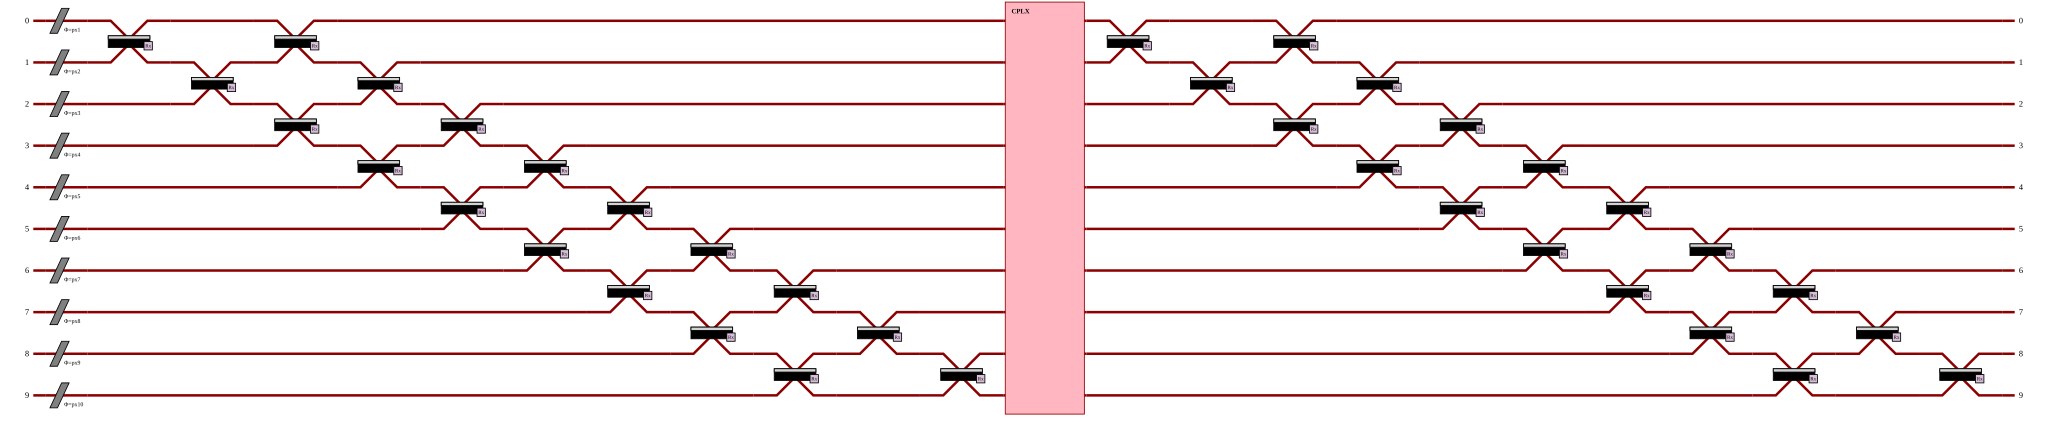

In [70]:
pcvl_circuit = quantum_layer.circuit

print(pcvl_circuit)
pcvl.pdisplay(pcvl_circuit)

recurruent evolution - memory lives in psi

In [36]:
def run_quantum_reservoir(X_np):

    Z = []
    z_prev = torch.zeros(q_dim).to(device)

    for t in range(len(X_np)):

        alpha = torch.tensor(X_np[t], dtype=torch.float32).to(device)

        # Scale input (important for stability)
        alpha_scaled = 0.5 * alpha

        # Feedback memory (paper-inspired)
        feedback_part = z_prev[:r]

        alpha_eff = torch.cat([alpha_scaled, feedback_part], dim=0)

        z = quantum_layer(alpha_eff.unsqueeze(0)).squeeze(0)

        Z.append(z.detach().cpu().numpy())
        z_prev = z.detach()

    return np.array(Z)


In [37]:
print("Generating quantum features...")

Z_train = run_quantum_reservoir(X_train)
Z_test  = run_quantum_reservoir(X_test)

print("Z_train shape:", Z_train.shape)

Generating quantum features...
Z_train shape: (394, 2002)


In [ ]:

#RIDGE READOUT


Z_train_aug = np.hstack([Z_train, np.ones((Z_train.shape[0], 1))])
Z_test_aug  = np.hstack([Z_test,  np.ones((Z_test.shape[0], 1))])

lambda_reg = 1e-4
I = np.eye(Z_train_aug.shape[1])

W_ridge = np.linalg.inv(
    Z_train_aug.T @ Z_train_aug + lambda_reg * I
) @ Z_train_aug.T @ Y_train

Y_pred_residual = Z_test_aug @ W_ridge  # predicted ΔX


#RECONSTRUCT NEXT FACTOR LEVEL


X_test_current = X_test
X_pred_next = X_test_current + Y_pred_residual


#PCA-Space Metrics


pca_mse = np.mean((X_pred_next - factors[split+1:])**2, axis=0)

print("\nPCA Component MSE:")
for i, mse in enumerate(pca_mse):
    print(f"PC{i}: {mse:.6f}")

pca_rmse = np.sqrt(pca_mse)
relative_rmse = pca_rmse / np.std(factors[split+1:], axis=0)

print("\nPCA Relative RMSE (%):")
for i, rel in enumerate(relative_rmse):
    print(f"PC{i}: {rel*100:.2f}%")


#SURFACE RECONSTRUCTION


Y_pred_surface_scaled = pca.inverse_transform(X_pred_next)
Y_test_surface_scaled = pca.inverse_transform(factors[split+1:])

Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)

print("\nSurface MSE:", surface_mse)


PCA Component MSE:
PC0: 6.426377
PC1: 0.714022
PC2: 0.541934
PC3: 0.009249
PC4: 0.002847

PCA Relative RMSE (%):
PC0: 36.04%
PC1: 20.91%
PC2: 29.51%
PC3: 42.23%
PC4: 24.85%

Surface MSE: 1.3072099329296622e-05


In [ ]:
# # Quantum layer
# quantum_layer = ML.QuantumLayer.simple(
#     input_size=r * 1   # because we concatenate memory
# ).to(device)


# class RecurrentQuantumReservoir(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
        
#         self.quantum = quantum_layer
        
#         # Automatically infer quantum output size
#         dummy = torch.zeros(1, input_dim * 2)
#         with torch.no_grad():
#             q_out_dim = self.quantum(dummy).shape[-1]
        
#         self.projection = nn.Linear(q_out_dim, input_dim)
#         self.readout = nn.Linear(input_dim, input_dim)

#     def forward(self, X):
#         outputs = []
#         z_prev = torch.zeros(X.shape[1], device=X.device)

#         for t in range(X.shape[0]):
#             x_aug = torch.cat([X[t], z_prev])
            
#             z_full = self.quantum(x_aug.unsqueeze(0)).squeeze(0)
            
#             z = self.projection(z_full)  # projection
            
#             y = self.readout(z)
            
#             outputs.append(y)
#             z_prev = z.detach()

#         return torch.stack(outputs)


In [ ]:
# class RecurrentQuantumReservoir(nn.Module):
#     def __init__(self, input_dim=5, modes=5):
#         super().__init__()
#         self.modes = modes
#         self.readout = nn.Linear(modes, input_dim)

#     def forward(self, X):

#         outputs = []
#         z_prev = np.zeros(self.modes)

#         # Ensure tensor
#         if isinstance(X, np.ndarray):
#             X = torch.tensor(X, dtype=torch.float32)

#         for t in range(X.shape[0]):
#             alpha = X[t].detach().cpu().numpy()

#             z = quantum_step(alpha, z_prev)
#             z_prev = z.copy()

#             z_tensor = torch.tensor(z, dtype=torch.float32).to(X.device)

#             y = self.readout(z_tensor)
#             outputs.append(y)

#         return torch.stack(outputs)

In [40]:
Y_pred_test = Z_test_aug @ W_ridge

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Flatten surfaces
y_true_flat = Y_test_surface.flatten()
y_pred_flat = Y_pred_surface.flatten()

MAE = mean_absolute_error(y_true_flat, y_pred_flat)
MSE = mean_squared_error(y_true_flat, y_pred_flat)
RMSE = np.sqrt(MSE)

print("\n===== SURFACE METRICS =====")
print(f"MAE  : {MAE:.8f}")
print(f"MSE  : {MSE:.8f}")
print(f"RMSE : {RMSE:.8f}")


===== SURFACE METRICS =====
MAE  : 0.00270515
MSE  : 0.00001307
RMSE : 0.00361554


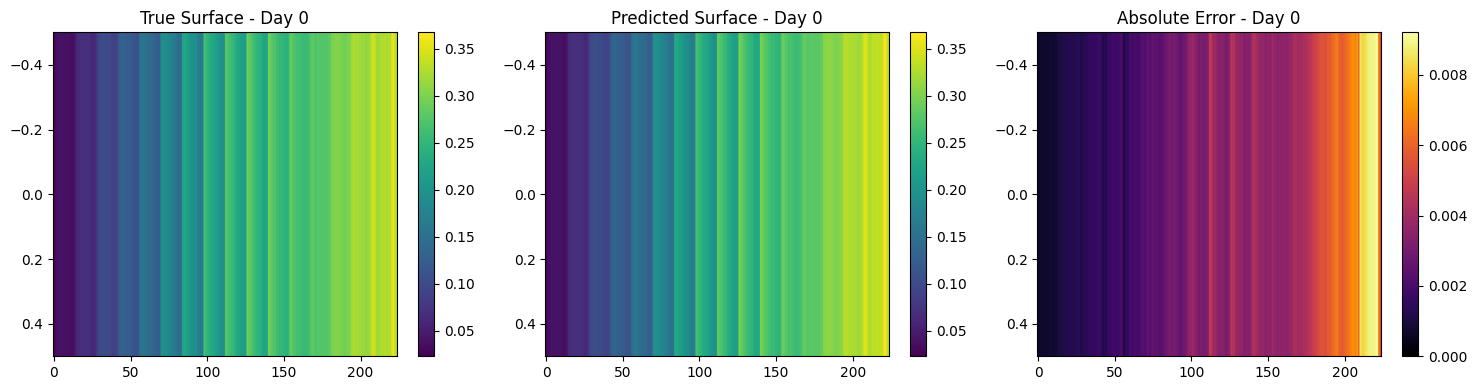

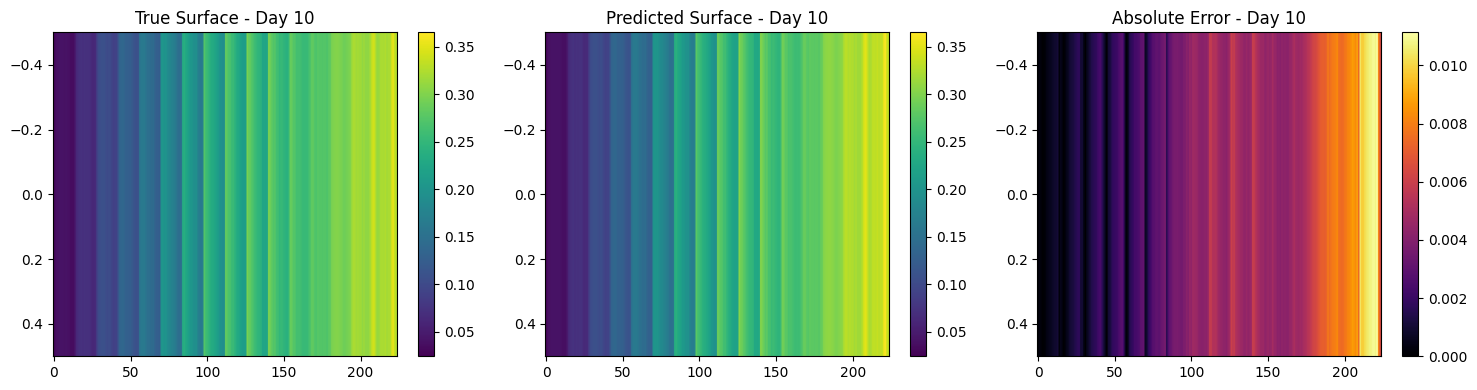

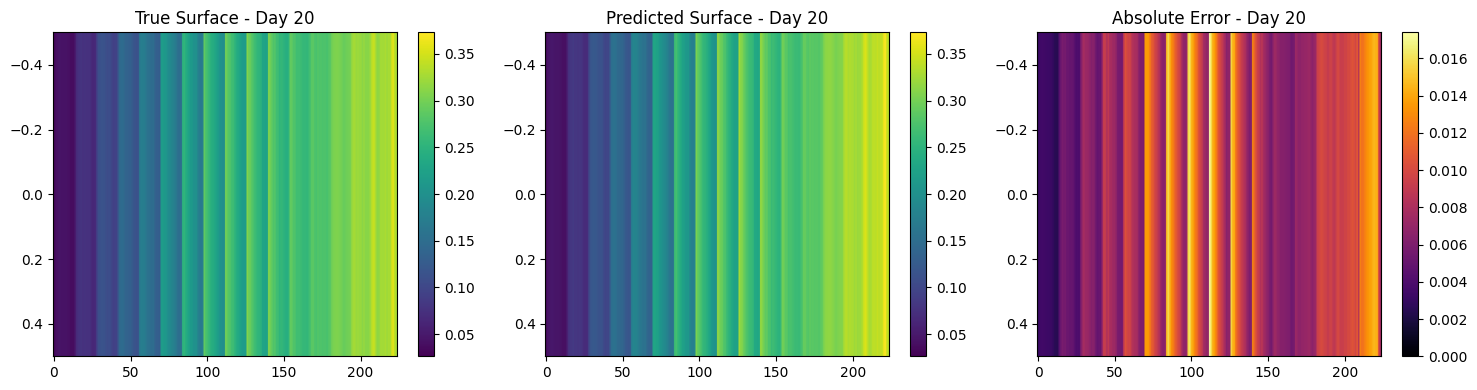

In [47]:
days_to_plot = [0, 10, 20]

for day in days_to_plot:

    true_surface = Y_test_surface[day]
    pred_surface = Y_pred_surface[day]
    abs_error_surface = np.abs(true_surface - pred_surface)

    # Shared scale for true & predicted
    vmin = min(true_surface.min(), pred_surface.min())
    vmax = max(true_surface.max(), pred_surface.max())

    # Error scale
    err_vmin = 0
    err_vmax = abs_error_surface.max()

    plt.figure(figsize=(15,4))

    # True Surface
    plt.subplot(1,3,1)
    im1 = plt.imshow(true_surface.reshape(1,-1),
                     aspect="auto",
                     vmin=vmin,
                     vmax=vmax,
                     cmap="viridis")
    plt.title(f"True Surface - Day {day}")
    plt.colorbar(im1)

    # Predicted Surface
    plt.subplot(1,3,2)
    im2 = plt.imshow(pred_surface.reshape(1,-1),
                     aspect="auto",
                     vmin=vmin,
                     vmax=vmax,
                     cmap="viridis")
    plt.title(f"Predicted Surface - Day {day}")
    plt.colorbar(im2)

    # Absolute Error
    plt.subplot(1,3,3)
    im3 = plt.imshow(abs_error_surface.reshape(1,-1),
                     aspect="auto",
                     vmin=err_vmin,
                     vmax=err_vmax,
                     cmap="inferno")
    plt.title(f"Absolute Error - Day {day}")
    plt.colorbar(im3)

    plt.tight_layout()
    plt.show()

In [63]:


surface_cols = [col for col in df.columns if col != "Date"]

tenors = []
maturities = []

for col in surface_cols:
    t = float(re.search(r"Tenor : (.*?);", col).group(1))
    m = float(re.search(r"Maturity : (.*)", col).group(1))
    tenors.append(t)
    maturities.append(m)

tenors = np.array(tenors)
maturities = np.array(maturities)

unique_tenors = np.sort(np.unique(tenors))
unique_maturities = np.sort(np.unique(maturities))

n_t = len(unique_tenors)
n_m = len(unique_maturities)

print("Grid size:", n_t, "x", n_m)

Grid size: 14 x 16


In [50]:
def reshape_surface(flat_surface):
    surface_grid = np.zeros((n_t, n_m))
    for i, (t, m) in enumerate(zip(tenors, maturities)):
        t_idx = np.where(unique_tenors == t)[0][0]
        m_idx = np.where(unique_maturities == m)[0][0]
        surface_grid[t_idx, m_idx] = flat_surface[i]
    return surface_grid

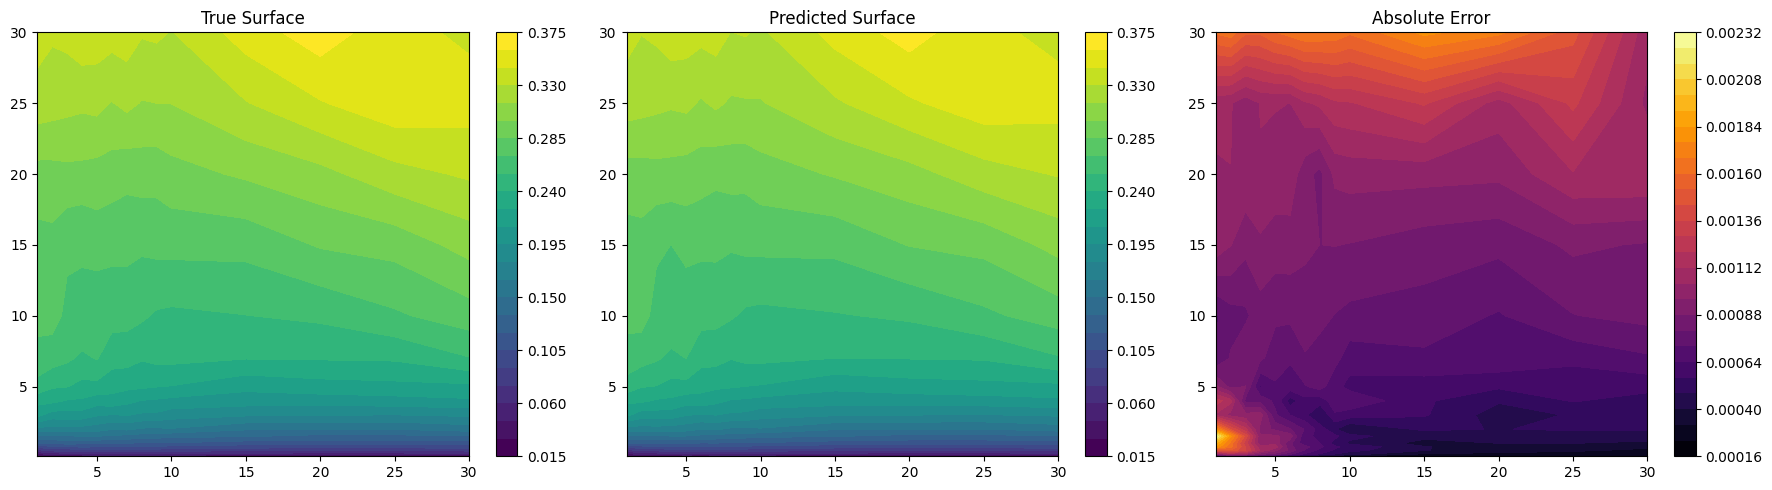

In [52]:
day_idx = 95  # make sure this index exists

true_surface = reshape_surface(Y_test_surface[day_idx])
pred_surface = reshape_surface(Y_pred_surface[day_idx])

abs_error_surface = np.abs(true_surface - pred_surface)

vmin = min(true_surface.min(), pred_surface.min())
vmax = max(true_surface.max(), pred_surface.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

c1 = axes[0].contourf(unique_tenors, unique_maturities,
                      true_surface.T,
                      levels=30,
                      vmin=vmin,
                      vmax=vmax,
                      cmap="viridis")
axes[0].set_title("True Surface")
fig.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(unique_tenors, unique_maturities,
                      pred_surface.T,
                      levels=30,
                      vmin=vmin,
                      vmax=vmax,
                      cmap="viridis")
axes[1].set_title("Predicted Surface")
fig.colorbar(c2, ax=axes[1])

c3 = axes[2].contourf(unique_tenors, unique_maturities,
                      abs_error_surface.T,
                      levels=30,
                      cmap="inferno")
axes[2].set_title("Absolute Error")
fig.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.show()

In [53]:
print(Y_test_surface.shape)
print(unique_tenors.shape)
print(unique_maturities.shape)

(99, 224)
(14,)
(16,)


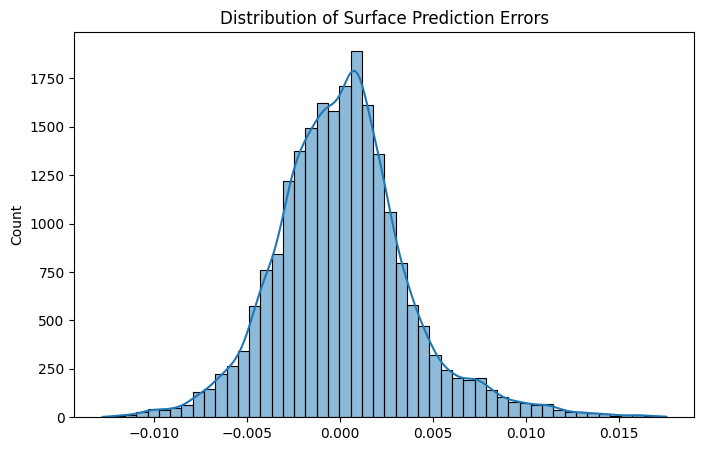

In [46]:
import seaborn as sns

error_surface = Y_pred_surface - Y_test_surface

plt.figure(figsize=(8,5))
sns.histplot(error_surface.flatten(), bins=50, kde=True)
plt.title("Distribution of Surface Prediction Errors")
plt.show()

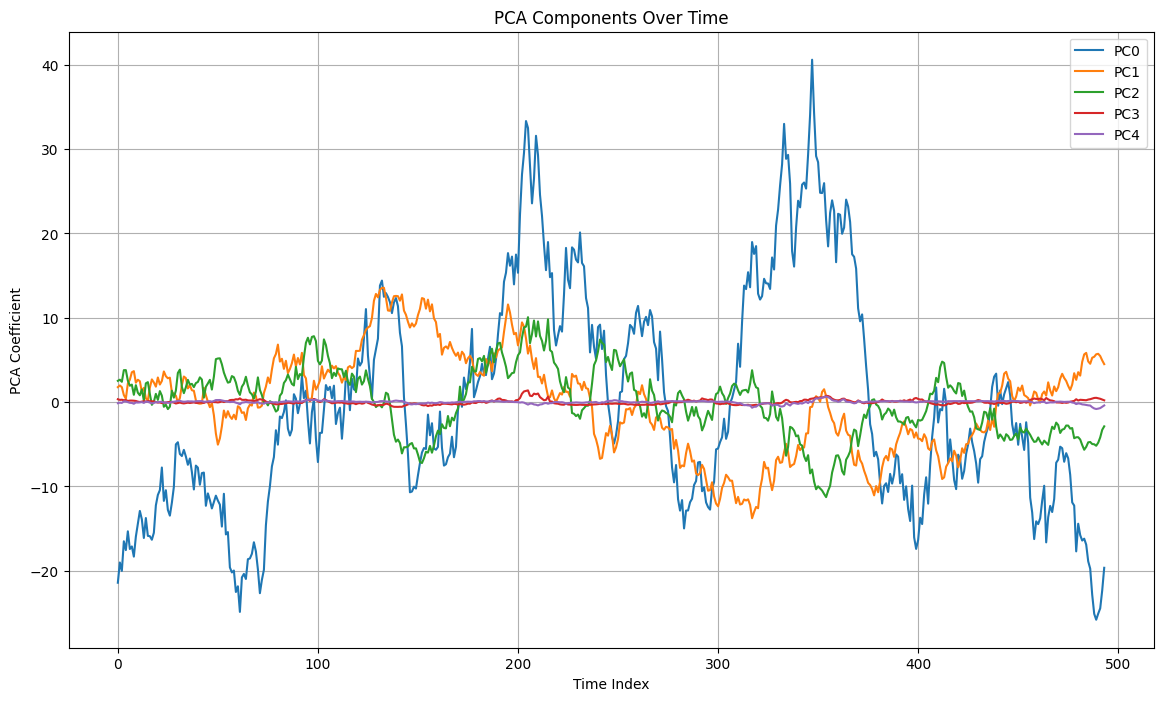

In [54]:
plt.figure(figsize=(14,8))

for i in range(5):
    plt.plot(factors[:, i], label=f"PC{i}")

plt.title("PCA Components Over Time")
plt.xlabel("Time Index")
plt.ylabel("PCA Coefficient")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
# Last known PCA level from dataset
last_factor = factors[-1].copy()

In [59]:
def forecast_next_steps(last_factor, steps=6):

    forecasts = []

    z_prev = torch.zeros(q_dim).to(device)
    current_factor = last_factor.copy()

    for _ in range(steps):

        alpha = torch.tensor(current_factor, dtype=torch.float32).to(device)

        alpha_scaled = 0.3 * alpha
        feedback_part = 0.5 * z_prev[:r]

        alpha_eff = torch.cat([alpha_scaled, feedback_part], dim=0)

        with torch.no_grad():
            z = quantum_layer(alpha_eff.unsqueeze(0)).squeeze(0)

        z_np = z.cpu().numpy()

        # Ridge residual prediction
        z_aug = np.append(z_np, 1.0)
        delta_pred = z_aug @ W_ridge

        # Update PCA level
        current_factor = current_factor + delta_pred

        forecasts.append(current_factor.copy())
        z_prev = z.detach()

    return np.array(forecasts)

In [60]:
future_pca_levels = forecast_next_steps(last_factor, steps=6)
print("Future PCA shape:", future_pca_levels.shape)

Future PCA shape: (6, 5)


In [61]:
future_surface_scaled = pca.inverse_transform(future_pca_levels)
future_surfaces = scaler.inverse_transform(future_surface_scaled)

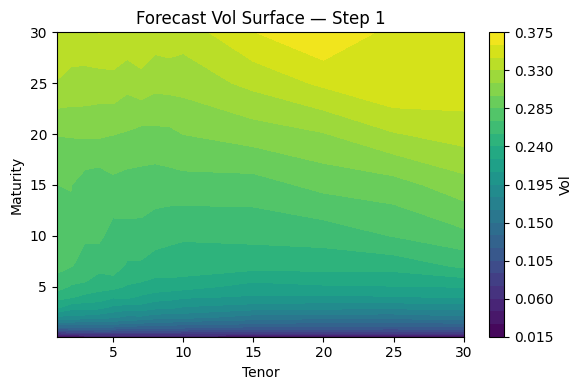

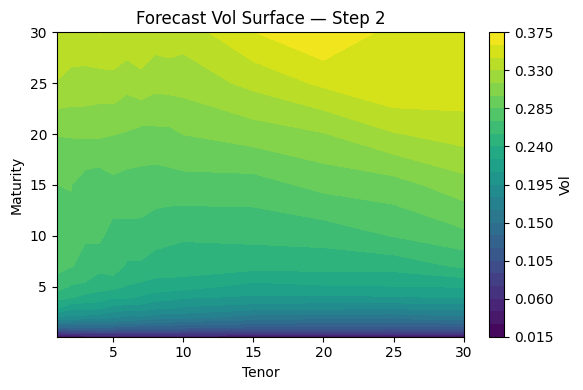

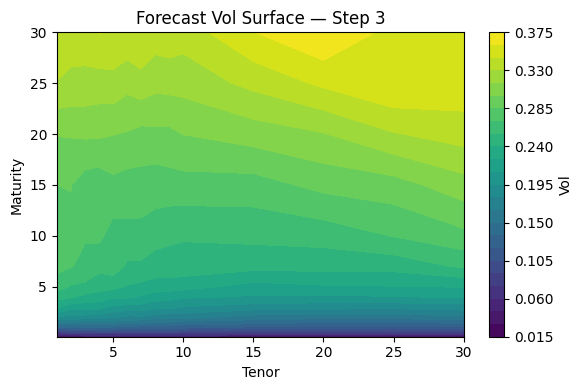

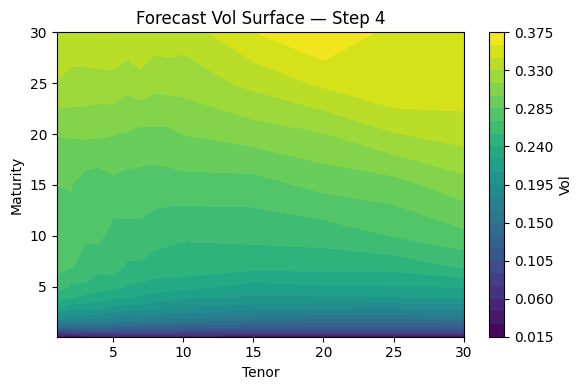

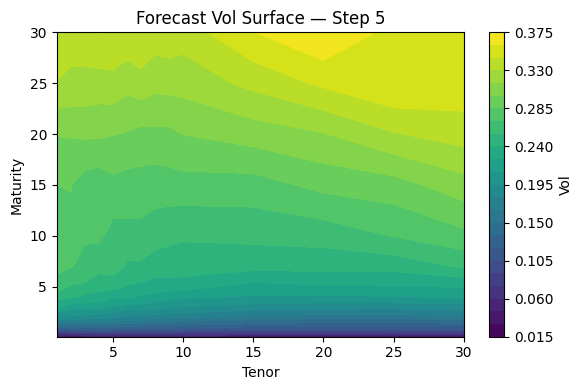

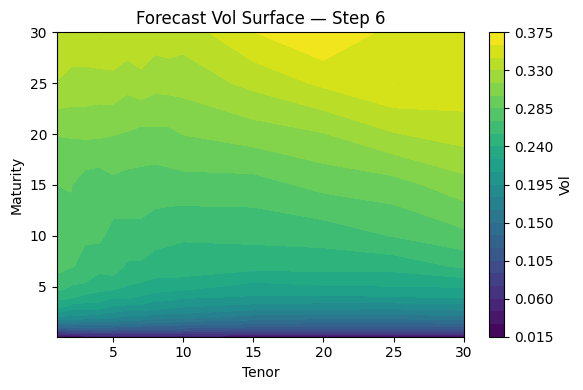

In [65]:
for i in range(6):

    surface = reshape_surface(future_surfaces[i])

    plt.figure(figsize=(6,4))
    plt.contourf(unique_tenors,
                 unique_maturities,
                 surface.T,
                 levels=30,
                 cmap="viridis")
    plt.title(f"Forecast Vol Surface — Step {i+1}")
    plt.xlabel("Tenor")
    plt.ylabel("Maturity")
    plt.colorbar(label="Vol")
    plt.tight_layout()
    plt.show()

In [ ]:

# Use original surface column names
surface_cols = [col for col in df.columns if col != "Date"]

# Create dataframe for forecasts
future_df = pd.DataFrame(future_surfaces, columns=surface_cols)

# Optional: Add step index column
future_df.insert(0, "Forecast_Step", [f"t+{i+1}" for i in range(6)])

# Save CSV
future_df.to_csv("future_6_step_vol_forecast.csv", index=False)

print("CSV file saved as: future_6_step_vol_forecast.csv")

CSV file saved as: future_6_step_vol_forecast.csv
